# Project Objective

### The goal of this project is to analyze Netflix's catalog to identify trends in content type, release patterns, ratings, and geographic distribution.

In [5]:
# Importing libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
os.getcwd()

'C:\\Users\\Clint\\anaconda_projects\\764fb97b-7391-492e-8351-5ed4cef5f42c'

In [11]:
# Loading the dataset
df = pd.read_csv('netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [33]:
# Inspecting the dataset
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 8702 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8702 non-null   object        
 1   type           8702 non-null   object        
 2   title          8702 non-null   object        
 3   director       6164 non-null   object        
 4   cast           7885 non-null   object        
 5   country        8702 non-null   object        
 6   date_added     8702 non-null   datetime64[ns]
 7   release_year   8702 non-null   int64         
 8   rating         8702 non-null   object        
 9   duration       8702 non-null   object        
 10  listed_in      8702 non-null   object        
 11  description    8702 non-null   object        
 12  year_added     8702 non-null   int32         
 13  duration_int   8702 non-null   float64       
 14  duration_type  8702 non-null   object        
 15  movie_minutes  6126 non-nu

(8702, 17)

In [34]:
# Checking missing values
df.isnull().sum()

show_id             0
type                0
title               0
director         2538
cast              817
country             0
date_added          0
release_year        0
rating              0
duration            0
listed_in           0
description         0
year_added          0
duration_int        0
duration_type       0
movie_minutes    2576
tv_seasons       6126
dtype: int64

In [35]:
# Fixing the rating / duration issue
mask = df['rating'].str.contains('min', na = False)
df.loc[mask, 'duration'] = df.loc[mask, 'rating']
df.loc[mask, 'rating'] = pd.NA

df['rating'].value_counts(dropna = False)
df['duration'].value_counts(dropna = False)

duration
1 Season     1789
2 Seasons     384
3 Seasons     178
90 min        152
93 min        146
             ... 
208 min         1
5 min           1
16 min          1
186 min         1
191 min         1
Name: count, Length: 219, dtype: int64

In [36]:
# Filling blanks in country column with 'Unknown'
df['country'] = df['country'].fillna('Unknown')

In [37]:
# Fixing date variable
df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce')
df['year_added'] = df['date_added'].dt.year

In [42]:
# Preserving as much data as possible
df['rating'] = df['rating'].fillna('Unknown')
df = df.dropna(subset=['date_added', 'duration'])

In [47]:
# Creating a new variable to use for the duration variable
df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float) # Creating Variable for number only without descriptions
df['duration_type'] = df['duration'].str.extract('(min|Season|Seasons)') # Creating variable for types of duration descriptions
df['duration_type'] = df['duration_type'].replace({
   'Season' : 'Seasons'
}) # Making labels consistent
df['movie_minutes'] = df['duration_int'].where(df['duration_type'] == 'min' ) # Creating variable for movie minutes
df['tv_seasons'] = df['duration_int'].where(df['duration_type'] == 'Seasons' ) # Creating variable for tv seasons
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8702 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8702 non-null   object        
 1   type           8702 non-null   object        
 2   title          8702 non-null   object        
 3   director       6164 non-null   object        
 4   cast           7885 non-null   object        
 5   country        8702 non-null   object        
 6   date_added     8702 non-null   datetime64[ns]
 7   release_year   8702 non-null   int64         
 8   rating         8702 non-null   object        
 9   duration       8702 non-null   object        
 10  listed_in      8702 non-null   object        
 11  description    8702 non-null   object        
 12  year_added     8702 non-null   int32         
 13  duration_int   8702 non-null   float64       
 14  duration_type  8702 non-null   object        
 15  movie_minutes  6126 non-nu

In [48]:
#Movies vs TV shows
df['type'].value_counts()

type
Movie      6126
TV Show    2576
Name: count, dtype: int64

In [49]:
# Top 10 countries producing content
df['country'].value_counts().head(10)

country
United States     2775
India              971
Unknown            826
United Kingdom     403
Japan              240
South Korea        195
Canada             173
Spain              141
France             122
Mexico             110
Name: count, dtype: int64

In [55]:
# Most common ratings
df['rating'].value_counts()

rating
TV-MA       3183
TV-14       2133
TV-PG        838
R            799
PG-13        490
TV-Y7        330
TV-Y         300
PG           287
TV-G         212
NR            78
G             41
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64

In [56]:
df['listed_in'].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: object

In [57]:
# Split genres into list
df['genre_list'] = df['listed_in'].str.split(', ')
df[['genre_list', 'listed_in']].head()

,genre_list,listed_in
0,[Documentaries],Documentaries
1,"[International TV Shows, TV Dramas, TV Mysteries]","International TV Shows, TV Dramas, TV Mysteries"
2,"[Crime TV Shows, International TV Shows, TV Ac...","Crime TV Shows, International TV Shows, TV Act..."
3,"[Docuseries, Reality TV]","Docuseries, Reality TV"
4,"[International TV Shows, Romantic TV Shows, TV...","International TV Shows, Romantic TV Shows, TV ..."


In [58]:
# Turning one row with 3 genres into 3 rows, one for each genre
genres_exploded = df.explode('genre_list')
genres_exploded['genre_list'].value_counts().head(10)

genre_list
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1327
Documentaries                869
Action & Adventure           859
Independent Movies           756
TV Dramas                    739
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

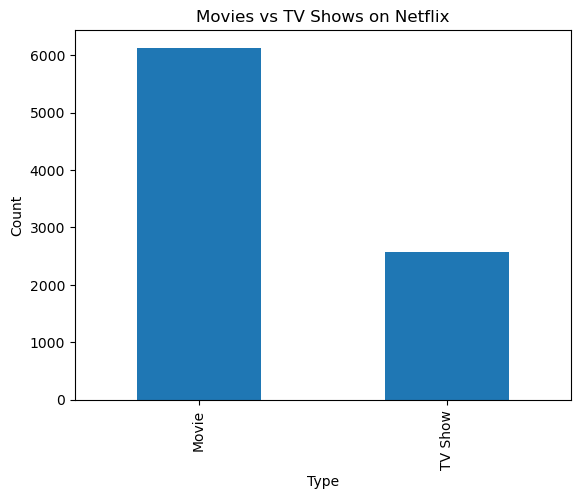

In [59]:
# VISUALS - Movies vs TV shows

df['type'].value_counts().plot(kind='bar')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

# Netflix has significantly more movies than TV Shows

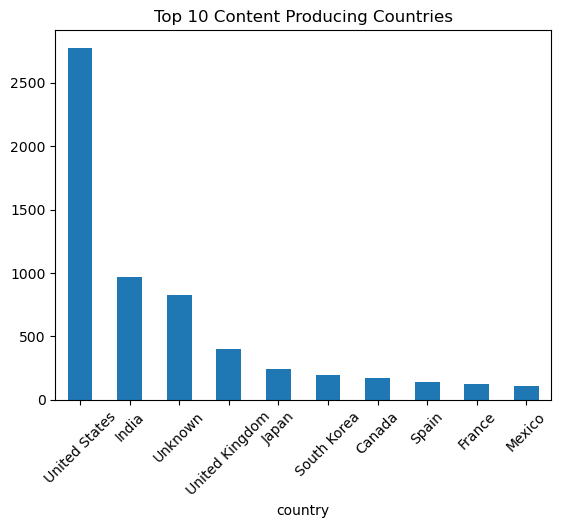

In [60]:
# Top Countries producing content
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Content Producing Countries')
plt.xticks(rotation=45)
plt.show()

# The U.S. dominates Netflix content producing by a large margin

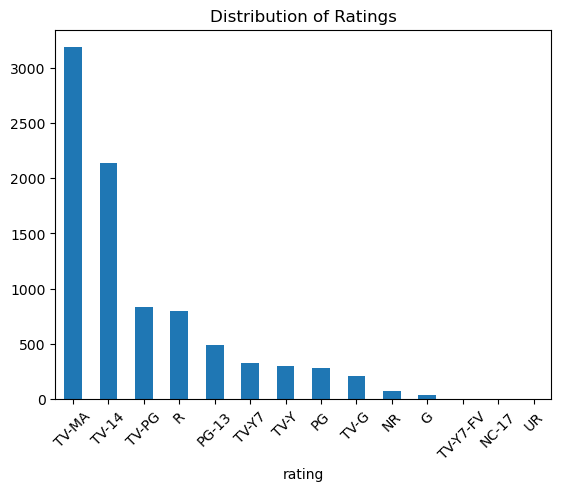

In [61]:
# Ratings Distribution
df['rating'].value_counts().plot(kind='bar')
plt.title('Distribution of Ratings')
plt.xticks(rotation=45)
plt.show()

# TV-MA is the most produced rating on Netflix

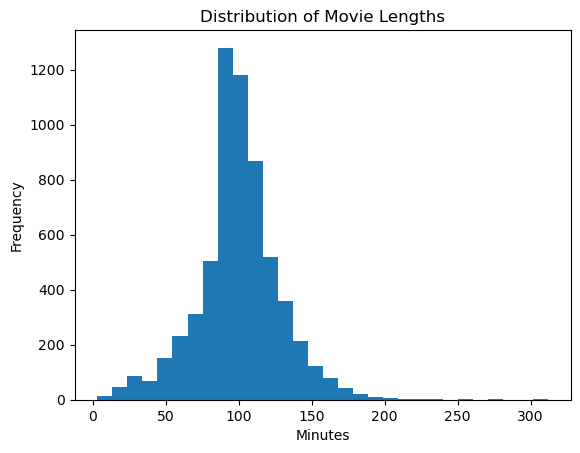

In [62]:
# Movie Length Distribution
df['movie_minutes'].dropna().plot(kind='hist', bins=30)
plt.title('Distribution of Movie Lengths')
plt.xlabel('Minutes')
plt.show()

# Most movies cluster around 90-120 minutes

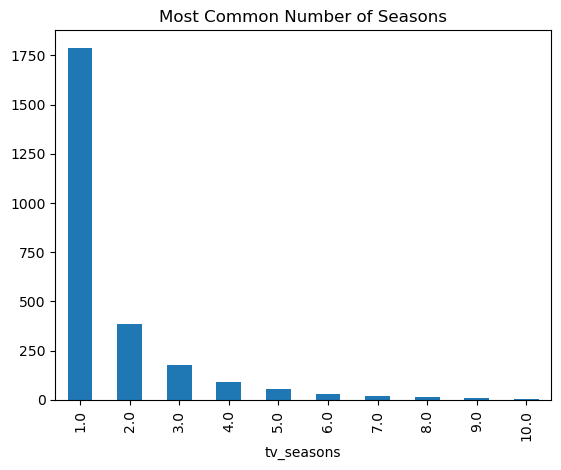

In [63]:
# TV Seasons distribution
df['tv_seasons'].dropna().value_counts().head(10).plot(kind='bar')
plt.title('Most Common Number of Seasons')
plt.show()

# Most TV shows only have 1-2 seasons

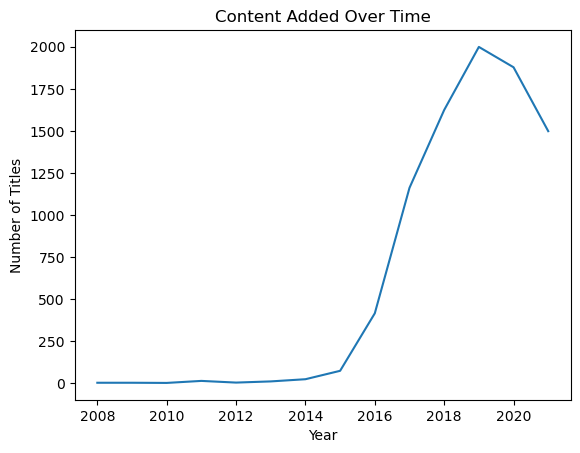

In [64]:
# Time trend


df['year_added'].value_counts().sort_index().plot(kind = 'line')
plt.title('Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

# Netflix saw rapid content growth after ~2015

In [65]:
# Average movie length by rating
df.groupby('rating')['movie_minutes'].mean().sort_values(ascending = False)

# Higher-rated (mature) content tends to be longer

rating
NC-17       125.000000
TV-14       110.290820
PG-13       108.330612
R           106.720201
UR          106.333333
PG           98.282230
TV-MA        95.889913
TV-PG        94.851852
NR           94.533333
G            90.268293
TV-G         79.666667
TV-Y7-FV     68.400000
TV-Y7        66.287770
TV-Y         48.114504
Name: movie_minutes, dtype: float64

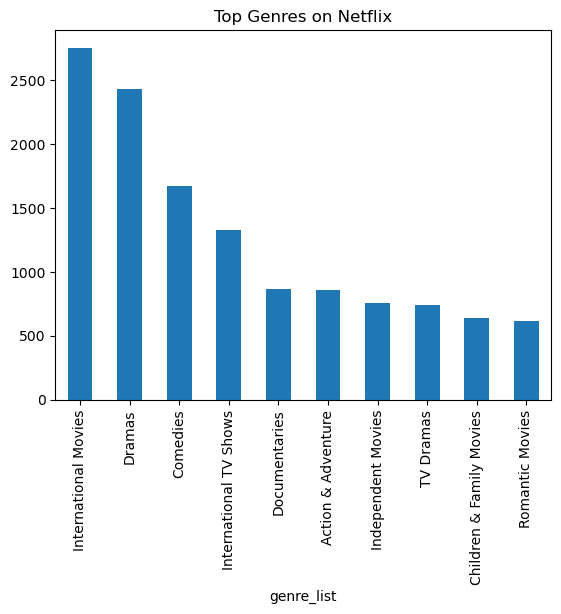

In [66]:
# Top Genres
genres_exploded['genre_list'].value_counts().head(10).plot(kind = 'bar')
plt.title('Top Genres on Netflix')
plt.show()

# Drama and International content dominate Netflix

In [67]:
# Which countries produce longer movies?

df.groupby('country')['movie_minutes'].mean().sort_values(ascending = False).head(10)

# Here are the top 10 countries that produce the longest movies.

country
United Kingdom, United States, Japan                   208.0
United States, United Kingdom, Morocco                 205.0
United States, Italy, United Kingdom, Liechtenstein    200.0
New Zealand, United States                             190.0
Romania, France, Switzerland, Germany                  186.0
France, Belgium, Spain                                 180.0
Germany, United States, Hong Kong, Singapore           172.0
India, Soviet Union                                    161.5
United Kingdom, United States, Morocco                 161.0
India, United Kingdom                                  160.0
Name: movie_minutes, dtype: float64